## Imports

In [1]:
from pathlib import Path
import numpy as np
import xarray as xr

from flood_adapt import FloodAdapt
from flood_adapt.config.config import Settings

## Config

In [5]:
# FloodAdapt databse inputs
DATA_DIR = Path(r"C:\repos\DYNAMO-M")
# DATA_DIR = Path(r"c:\Users\winter_ga\Offline_data\FloodAdapt-WorkingDatabase\Charleston\4_FloodAdapt\Database")

site = "charleston_beta_release"

# Monte Carlo input parameters for event sequences
timestep = 1  # timestep of Monte Carlo in years
sim_time = 30  # length of simulation in years
no_seq = 1000  # number of event sequences to generate
seed = 42  # random seed for reproducibility

# SLR scenario to evaluate damages over time
slr_scenario_name = "NOAA High" # This needs to be a scenario in the FloodAdapt database

# lookup table
ds_impacts = xr.open_dataset(DATA_DIR / "lookup_table_charleston_beta_release_ABM_probabilistic_set.nc")

KeyboardInterrupt: 

In [3]:
times = 2020 + np.linspace(0, sim_time, int(sim_time / timestep) + 1)
times

array([2020., 2021., 2022., 2023., 2024., 2025., 2026., 2027., 2028.,
       2029., 2030., 2031., 2032., 2033., 2034., 2035., 2036., 2037.,
       2038., 2039., 2040., 2041., 2042., 2043., 2044., 2045., 2046.,
       2047., 2048., 2049., 2050.])

## Initialize FloodAdapt Database

In [4]:
settings = Settings(
    DATABASE_ROOT=DATA_DIR,
    DATABASE_NAME=site,
)
fa = FloodAdapt(database_path=settings.database_path)
slr_values = [fa.interp_slr(slr_scenario=slr_scenario_name, year=time) for time in times]

2025-12-22 10:42:38 AM - FloodAdapt.Database - INFO - Initializing database to charleston_beta_release at c:\users\athanasi\github\database\working_databases\charleston\4_floodadapt\database


In [5]:
ds_impacts

<xarray.Dataset> Size: 2GB
Dimensions:       (object_id: 61858, slr: 5, strategy: 2, event: 207)
Coordinates:
  * object_id     (object_id) <U1598 395MB '14048' '67199' ... '70438' '70444'
  * slr           (slr) float64 40B 0.0 0.5 1.0 1.5 2.0
  * strategy      (strategy) <U16 128B 'no_measures' 'floodproof_all_0'
  * event         (event) <U10 8kB 'event_0000' 'event_0001' ... 'track_0122'
Data variables:
    inun_depth    (object_id, slr, strategy, event) float64 1GB ...
    total_damage  (object_id, slr, strategy, event) float64 1GB ...

In [6]:

from floodadapt_abm import ABMSimulator

# Instantiate the simulator (event sequence and damage lookup are handled internally)
abm = ABMSimulator(
    ds_impacts=ds_impacts,
    times=times,
    slr_values=slr_values,
    no_seq=no_seq,
    damage_threshold=0.3,  # You can change this threshold as needed
    seed=seed,
    dmg_unit="$",
    slr_unit="feet"
)

In [7]:
# Run the simulation
abm.run_simulation("linear")

[LOOKUP] Interpolating damage matrix for strategy 'no_measures' using method 'linear'...
[BASELINE] Evaluating sequence 1000/1000...
[LOOKUP] Interpolating damage matrix for strategy 'no_measures' using method 'linear'...
[LOOKUP] Interpolating damage matrix for strategy 'floodproof_all_0' using method 'linear'...
[ADAPTATION] Evaluating sequence 1000/1000...
Evaluation completed.


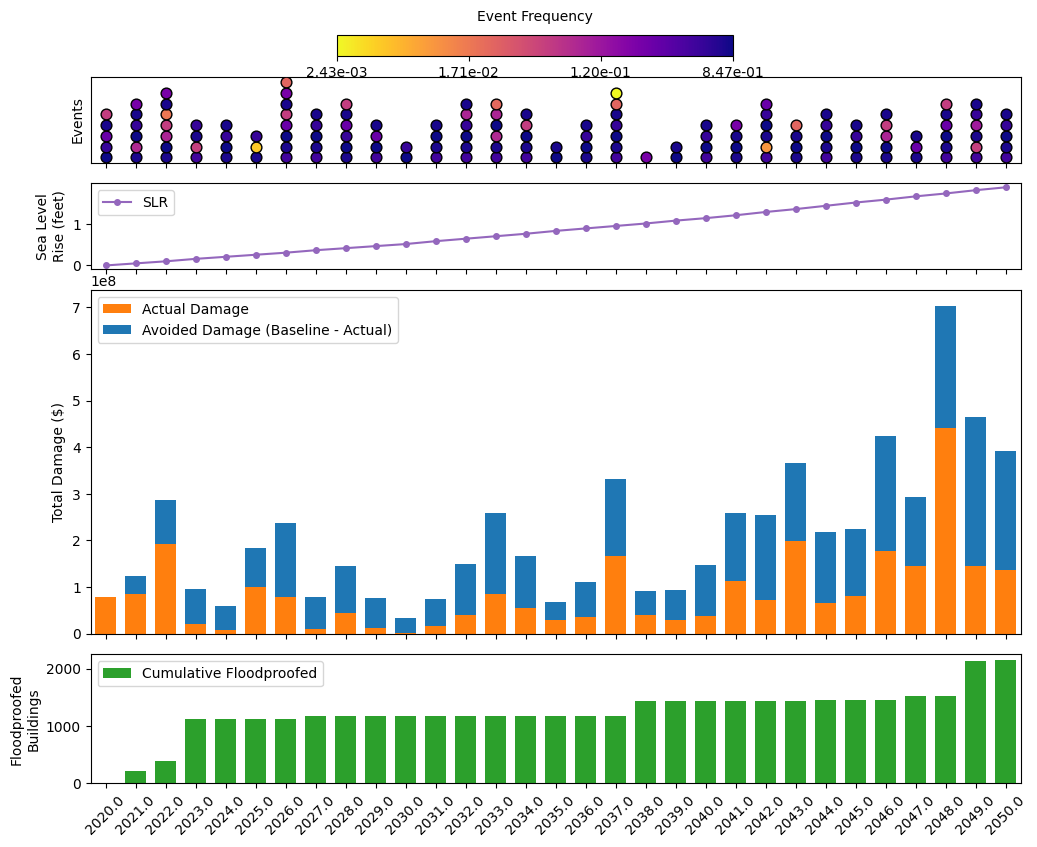

In [8]:
abm.plot_event_damage_timeseries(0)

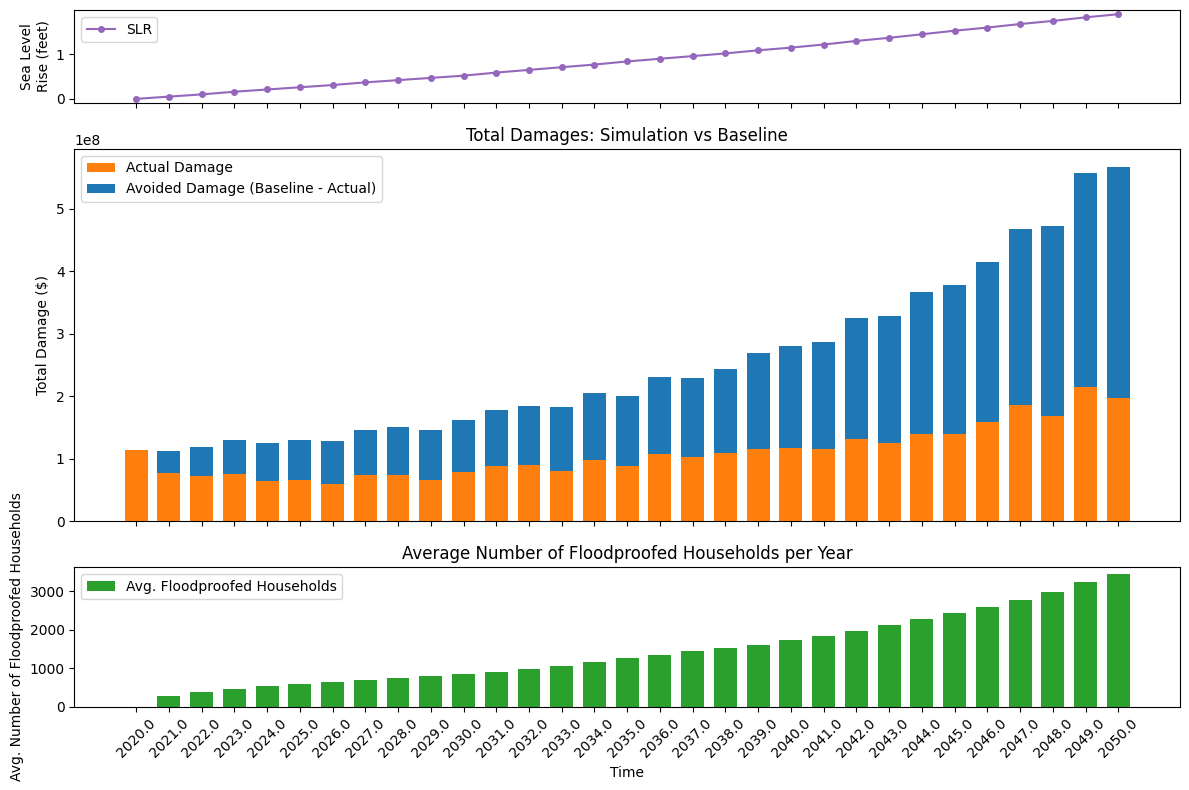

In [9]:
abm.plot_total_damage_statistics()